In [1]:
from langgraph.graph import StateGraph ,START , END
from typing import TypedDict


In [2]:
from typing import TypedDict

class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float
    result: str 

In [3]:
def calculate_bmi(state: BMIState):
    bmi = state["weight"] / (state["height"] ** 2)

    return {
        "bmi": round(bmi, 2)
    }

In [4]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [5]:
def getllmresponse(state: BMIState):

    prompt = f"""
    You are a professional fitness and nutrition coach.

    User Details:
    Weight: {state['weight']} kg
    Height: {state['height']} m
    BMI: {state['bmi']}

    Based on the BMI:
    1. Tell the BMI category.
    2. Explain what it means.
    3. Give diet suggestions.
    4. Give exercise suggestions.
    5. Mention precautions.
    6. Keep the answer simple and motivating.
    """

    response = llm.invoke(prompt)

    return {
        "result": response.content
    }

In [28]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [7]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(BMIState)

# Nodes
graph.add_node("calculate_bmi", calculate_bmi)
graph.add_node("llm_response", getllmresponse)

# Edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "llm_response")
graph.add_edge("llm_response", END)

workflow = graph.compile()

In [8]:
result = workflow.invoke({
    "weight": 70,
    "height": 1.75
})

print(result["result"])

**Your BMI Category: Normal Weight**

 Congratulations, you have a BMI of 22.86, which falls under the normal weight category. This means you're at a healthy weight for your height.

**What does it mean?**

Having a normal BMI indicates that your weight is neither too high nor too low for your height. It's a good indicator of your overall health and reduces the risk of chronic diseases like diabetes, heart disease, and certain types of cancer.

**Diet Suggestions:**

1. **Eat a balanced diet**: Focus on whole foods like fruits, vegetables, whole grains, lean proteins, and healthy fats.
2. **Watch your portion sizes**: Make sure you're not overeating or under-eating. Eat until you're satisfied, not stuffed.
3. **Stay hydrated**: Drink plenty of water throughout the day.
4. **Avoid processed foods**: Limit your intake of packaged snacks and sugary drinks.
5. **Incorporate healthy fats**: Nuts, seeds, avocados, and olive oil are great sources of healthy fats.

**Exercise Suggestions:**

1

In [9]:
print(result)

{'weight': 70, 'height': 1.75, 'bmi': 22.86, 'result': "**Your BMI Category: Normal Weight**\n\n Congratulations, you have a BMI of 22.86, which falls under the normal weight category. This means you're at a healthy weight for your height.\n\n**What does it mean?**\n\nHaving a normal BMI indicates that your weight is neither too high nor too low for your height. It's a good indicator of your overall health and reduces the risk of chronic diseases like diabetes, heart disease, and certain types of cancer.\n\n**Diet Suggestions:**\n\n1. **Eat a balanced diet**: Focus on whole foods like fruits, vegetables, whole grains, lean proteins, and healthy fats.\n2. **Watch your portion sizes**: Make sure you're not overeating or under-eating. Eat until you're satisfied, not stuffed.\n3. **Stay hydrated**: Drink plenty of water throughout the day.\n4. **Avoid processed foods**: Limit your intake of packaged snacks and sugary drinks.\n5. **Incorporate healthy fats**: Nuts, seeds, avocados, and oliv

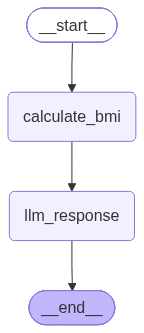

In [10]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [11]:
from pydantic import BaseModel , Field
from dotenv import load_dotenv

In [12]:
class feedbacksession(BaseModel):
    feedback : str 
    score : int 

In [13]:
structured_output = llm.with_structured_output(feedbacksession)

In [14]:
essays = """# Who is Mahatma Gandhi?

Mahatma Gandhi, whose full name was Mohandas Karamchand Gandhi, was one of the greatest leaders in the history of India. He is known as the "Father of the Nation" because of his significant role in India's struggle for independence from British rule. Gandhi was born on October 2, 1869, in Porbandar, Gujarat.

Gandhi studied law in England and later worked in South Africa, where he experienced racial discrimination. These experiences inspired him to fight against injustice through peaceful means. He believed in the principles of truth (*Satya*) and non-violence (*Ahimsa*), which became the foundation of his movements.

After returning to India, Gandhi led several important movements, including the Non-Cooperation Movement, the Civil Disobedience Movement, and the Quit India Movement. One of his most famous protests was the Dandi Salt March in 1930, where he opposed the British salt tax through peaceful protest. His leadership inspired millions of Indians to join the freedom struggle.

Gandhi believed that real strength comes from peace, honesty, and self-discipline. He encouraged people to wear *khadi* (hand-spun cloth), promote village industries, and live simple lives. His teachings continue to inspire people around the world to solve conflicts without violence.

On January 30, 1948, Mahatma Gandhi was assassinated in New Delhi. Although he is no longer alive, his ideas and values remain influential across the world. Every year, his birthday, October 2, is celebrated as Gandhi Jayanti in India and as the International Day of Non-Violence by the United Nations.

In conclusion, Mahatma Gandhi was a remarkable leader who showed that courage, truth, and non-violence can bring about great social and political change. His life continues to inspire people to work for peace, justice, and equality.
"""

In [15]:
prompts = f"give  me feedback and score of this essays here is {essays}"

structured_output.invoke(prompts)


feedbacksession(feedback="Your essay is well-written and provides a clear overview of Mahatma Gandhi's life and impact. The structure is logical, and the writing is concise. However, there are some minor errors in grammar and punctuation. The essay could benefit from more in-depth analysis and specific examples to support the claims made. Overall, the essay shows a good understanding of the subject but requires further development to reach its full potential.", score=8)

In [16]:
query = "what is full form of ai"
result = llm.invoke(query)
print(result.content)

The full form of AI is Artificial Intelligence.


In [12]:
from langchain_core.messages import BaseMessage , HumanMessage
from typing import Annotated , TypedDict
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph ,START , END

In [6]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage] ,add_messages] 
    

In [9]:
graphs = StateGraph(ChatState)

In [22]:
def chat_nodes(state : ChatState):
    messages = state['messages']

    response = llm.invoke(messages)
    return {
        "messages" : [response]
    }

In [23]:
# add nodes 

graphs.add_node('chat_nodes' , chat_nodes)

# add edges 

graphs.add_edge(START , 'chat_nodes')
graphs.add_edge('chat_nodes' , END)



In [25]:
chatbot = graphs.compile()

In [26]:
initial_node = {
    "messages" : HumanMessage(content='who is the prime minister of india')
}

In [32]:
chatbot.invoke(initial_node)

{'messages': [HumanMessage(content='who is the prime minister of india', additional_kwargs={}, response_metadata={}, id='e8bcf956-d670-453d-88be-50f55d4fbd6e'),
  AIMessage(content='As of my cut-off knowledge in 2023, the Prime Minister of India was Narendra Modi. However, I am not aware of any updates beyond that date.\n\nTo get the most recent and accurate information, I recommend checking a reliable news source or the official website of the Government of India.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 42, 'total_tokens': 102, 'completion_time': 0.087887523, 'completion_tokens_details': None, 'prompt_time': 0.005673494, 'prompt_tokens_details': None, 'queue_time': 0.053464855, 'total_time': 0.093561017}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc0fe-0576-7a53-8af9-a9905dfddb3

In [34]:
while True:

    user_input = input("Ente ther query here okay") 

    print("USer Enter :  " , user_input)

    if user_input.lower().strip() in ['exit' , 'by' , 'stop']:
        break

    response = chatbot.invoke({

        'messages' : [HumanMessage(content=user_input)]
    })

    result  = response['messages'][-1].content

    print(result)

USer Enter :   hi 
How can I assist you today?
USer Enter :   what is va;lus of pi
The value of pi (π) is an irrational number that represents the ratio of a circle's circumference to its diameter. It is approximately equal to 3.14159, but it is a non-repeating, non-terminating decimal.

Pi is often approximated to various decimal places depending on the application:

- 3.141 (two decimal places) is commonly used in everyday calculations.
- 3.14159 (five decimal places) is used in many mathematical and scientific applications.
- 3.141592653589793 (16 decimal places) is a more precise value.
- The current record for the value of pi is 31.4 trillion digits, set by a team of mathematicians in 2019.

Pi is often represented as an infinite decimal expansion, which can be calculated to any desired level of precision using various mathematical formulas and algorithms. Some of the key properties of pi include:

- Irrationality: Pi is an irrational number, which means it cannot be expressed as 

In [1]:
from langgraph.checkpoint.memory import InMemorySaver


In [9]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END

In [15]:
class jokesstate(TypedDict):
    topic:str 
    jokes:str
    explanation : str 
    

In [25]:
def generate_jock(state:jokesstate):
    prompts = f"generate a jocks  on this topics {state['topic']}"

    response = llm.invoke(prompts)

    return{
        "jokes" : response.content
    }

In [26]:
def jock_explanation(state:jokesstate):
    prompts = f"Generate jokes explanation of this topics {state['jokes']}"
    response = llm.invoke(prompts)

    return {
        'explanation' : response.content
    }

In [27]:
graph = StateGraph(jokesstate)

In [13]:
import os
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY"),
)

In [28]:
#add nodes 
graph.add_node('generate_jockes' , generate_jock)
graph.add_node('generate_explanation' , jock_explanation)

# add edges 

graph.add_edge(START , 'generate_jockes')
graph.add_edge('generate_jockes' , 'generate_explanation')
graph.add_edge('generate_explanation' , END)


checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [29]:
configs = {
    'configurable' : {"thread_id" : "1"}
}

workflow.invoke({"topic" : "pizza"} , config=configs)

{'topic': 'pizza',
 'jokes': "Here are some fun facts about pizza:\n\n**1. The Birthplace of Pizza**\nPizza originated in Naples, Italy in the late 18th or early 19th century. Before that, flatbreads were cooked in wood-fired ovens, but the modern version of pizza with tomato sauce and cheese was created by Raffaele Esposito in 1889.\n\n**2. The First Pizzeria**\nThe first pizzeria, Antica Pizzeria Port'Alba, was opened in Naples in 1738. It's still serving delicious pizzas today!\n\n**3. Fun Fact: The World's Largest Pizza**\nThe largest pizza ever made was over 13,000 square feet (1,200 square meters) and weighed over 51,000 pounds (23,136 kilograms). It was made in Rome, Italy in 1999.\n\n**4. The Original Pizza Toppings**\nThe original pizza toppings were tomato sauce, mozzarella cheese, and fresh basil leaves. Some say that's still the best combination!\n\n**5. The History of Cheese on Pizza**\nBefore the arrival of mozzarella cheese, pizza was topped with other types of cheese, s

In [30]:
workflow.get_state(configs)

StateSnapshot(values={'topic': 'pizza', 'jokes': "Here are some fun facts about pizza:\n\n**1. The Birthplace of Pizza**\nPizza originated in Naples, Italy in the late 18th or early 19th century. Before that, flatbreads were cooked in wood-fired ovens, but the modern version of pizza with tomato sauce and cheese was created by Raffaele Esposito in 1889.\n\n**2. The First Pizzeria**\nThe first pizzeria, Antica Pizzeria Port'Alba, was opened in Naples in 1738. It's still serving delicious pizzas today!\n\n**3. Fun Fact: The World's Largest Pizza**\nThe largest pizza ever made was over 13,000 square feet (1,200 square meters) and weighed over 51,000 pounds (23,136 kilograms). It was made in Rome, Italy in 1999.\n\n**4. The Original Pizza Toppings**\nThe original pizza toppings were tomato sauce, mozzarella cheese, and fresh basil leaves. Some say that's still the best combination!\n\n**5. The History of Cheese on Pizza**\nBefore the arrival of mozzarella cheese, pizza was topped with othe

In [31]:
list(workflow.get_state_history(configs))

[StateSnapshot(values={'topic': 'pizza', 'jokes': "Here are some fun facts about pizza:\n\n**1. The Birthplace of Pizza**\nPizza originated in Naples, Italy in the late 18th or early 19th century. Before that, flatbreads were cooked in wood-fired ovens, but the modern version of pizza with tomato sauce and cheese was created by Raffaele Esposito in 1889.\n\n**2. The First Pizzeria**\nThe first pizzeria, Antica Pizzeria Port'Alba, was opened in Naples in 1738. It's still serving delicious pizzas today!\n\n**3. Fun Fact: The World's Largest Pizza**\nThe largest pizza ever made was over 13,000 square feet (1,200 square meters) and weighed over 51,000 pounds (23,136 kilograms). It was made in Rome, Italy in 1999.\n\n**4. The Original Pizza Toppings**\nThe original pizza toppings were tomato sauce, mozzarella cheese, and fresh basil leaves. Some say that's still the best combination!\n\n**5. The History of Cheese on Pizza**\nBefore the arrival of mozzarella cheese, pizza was topped with oth

In [ ]:
# this all is mainting the hostory right has 